# MIL-CREDA bajo ruido de etiqueta — la curva de degradación

Este cuaderno mide una sola cosa: **cuánto pierde cada método a medida que el
material de entrenamiento se contamina**, y si el orden entre métodos sobrevive.

La contaminación reemplaza parte de cada bolsa de entrenamiento por imágenes de
otra clase y **no toca la etiqueta de la bolsa**. Las bolsas son puras y ninguna
instancia lleva etiqueta propia, así que no hay nada que dar vuelta: lo que se
corrompe es la evidencia que una bolsa ofrece a favor de su propia etiqueta.

Esa misma sustitución es **dos perturbaciones distintas**, y esa asimetría es el
experimento y no un detalle. El cableado difunde la etiqueta de la bolsa a sus
treinta instancias, así que un brazo de unidad-instancia recibe instancias
genuinamente mal etiquetadas; un brazo de unidad-bolsa mantiene la etiqueta en la
bolsa y ve testigos que su atención puede aprender a despesar. Leída como una
sola perturbación, la tabla diría «mismo ruido, distinta robustez» cuando dice
«una contaminación, dos consecuencias que las formulaciones implican».

> **Sobre qué transferencia, y por qué esa.**
>
> Una sola, y elegida por la menor brecha de dominio — nunca por cuál dio mejor
> resultado. La regla es del instrumento: una transferencia que ya está cerca de
> su piso con ρ=0 no tiene de dónde caer y no puede mostrar una curva. La brecha
> es propiedad del material y no de ninguna medición, así que nada de lo que
> salga de acá pudo haberla elegido.
>
> **Los roles de selección y evaluación están limpios en todas las tasas.** El
> ruido vive en el material de entrenamiento y en ningún otro lado: `valid` es
> donde la búsqueda lee su criterio y `eval` es la clave de corrección del
> veredicto. Se entrena sucio y se mide limpio, así que el acierto siempre se
> mide contra las etiquetas verdaderas.
>
> **Y los techos se buscaron en limpio.** La curva es el coeficiente elegido sin
> contaminación aplicado con ella, que además es la situación práctica. Lo que
> eso cuesta es que una caída no se puede atribuir: el término fallando y el
> coeficiente quedándose corto se ven igual. Ese es exactamente el trabajo del
> cuaderno de diagnóstico, y no de este.

In [1]:
#!/usr/bin/env python3
"""The first code cell of every notebook a job may run — copied byte for byte.

One question, answered once: WHERE IS THE REPOSITORY THIS NOTEBOOK RUNS
AGAINST. Every later cell reads `ROOT` and none of them asks again.

Opened by a person on their own machine, this answers it exactly the way
these notebooks always have. A notebook lives at `<repo>/<Name>/Notebooks/`,
so the repository is two directories above the working directory. Nothing was
handed over, nothing is checked, and the behaviour is unchanged.

Started by a runner on a remote worker, it does not answer it by looking
around. The runner exports the directory it cloned the pinned commit into and
the commit it pinned; this cell reads both, and PROVES the checkout is at that
commit before returning it.

Guessing is the whole reason this cell exists. Under the runner the kernel's
working directory is the runner's own and the clone sits one level inside it,
so two directories up is two levels ABOVE the working directory — a directory
that EXISTS on any worker. The path resolves, the insert succeeds, and the run
dies later with a missing module naming a package, never with the wrong root.
The one fact worth having is the one the failure never mentions.

Three refusals, and each one is a refusal rather than a fallback because this
is the path that spends metered quota:

- **Half a handoff** — one variable present and the other missing. Something
  built this environment and got it half right; that is precisely the state a
  fallback cannot tell apart from a laptop, and the fallback resolves a
  directory that exists everywhere.
- **A root that is not a checkout** — the declared directory is missing, or
  holds no readable `HEAD`. There is nothing to compare against, and an
  unproven root is what this cell was written to stop being acceptable.
- **A checkout at a different commit** — the declared commit and the one on
  disk disagree. A job that runs the wrong commit RUNS: it returns numbers
  shaped exactly like the right ones, and nothing downstream can tell.

Absent means LOCAL. It never means "work it out".

Importable and independently testable, the way the runner's own two cells
are: every function is pure and takes its environment and its working
directory as arguments, and only the last line — the binding a notebook cell
exists to perform — reads the real ones.
"""
import os
from pathlib import Path

#: The directory a runner cloned the pinned commit into. Forge-owned and
#: deliberately generic: this is the contract between a runner and the
#: notebook it starts, not a name borrowed from any one repository.
CLONE_ROOT_ENV = "FORGE_CLONE_ROOT"

#: The commit that clone was pinned to, exported beside it so this cell can
#: check rather than trust. A root on its own would only move the guess one
#: step: a directory handed over is still a directory nobody proved.
CLONE_COMMIT_ENV = "FORGE_CLONE_COMMIT"

#: How far above a notebook's own directory the repository sits when nobody
#: hands anything over: `<repo>/<Name>/Notebooks` -> `<repo>`.
LOCAL_ROOT_DEPTH = 1


def head_commit(root):
    """The commit `root`'s `HEAD` names, read straight out of `.git`.

    No subprocess, deliberately. A notebook cell that shells out needs a git
    binary on a worker's PATH that nothing here declared, and every checker
    that reads these notebooks then has to decide whether running the cell is
    safe — a cell that binds the repository is the last one that may be
    skipped for that reason.

    A pinned checkout is detached: the runner fetches a commit and checks out
    what it fetched, never a branch, so `HEAD` holds the raw commit and this
    is a one-line read. A symbolic `HEAD` is resolved anyway — through the
    loose ref and then `packed-refs` — so pointing these variables at an
    ordinary checkout gets an answer instead of a refusal that would be about
    the file format rather than about the commit.

    Returns `None` when there is nothing to read. The caller turns that into
    a refusal; this function never decides.
    """
    git = Path(root) / ".git"
    if git.is_file():
        pointer = git.read_text(encoding="utf-8").strip()
        if not pointer.startswith("gitdir:"):
            return None
        git = Path(root) / pointer[len("gitdir:"):].strip()
    if not git.is_dir():
        return None
    head = git / "HEAD"
    if not head.is_file():
        return None
    text = head.read_text(encoding="utf-8").strip()
    if not text.startswith("ref:"):
        return text or None
    ref = text[len("ref:"):].strip()
    loose = git / ref
    if loose.is_file():
        return loose.read_text(encoding="utf-8").strip() or None
    packed = git / "packed-refs"
    if packed.is_file():
        for line in packed.read_text(encoding="utf-8").splitlines():
            if line.startswith("#") or line.startswith("^"):
                continue
            fields = line.split()
            if len(fields) == 2 and fields[1] == ref:
                return fields[0]
    return None


def resolve_repository_root(environ=None, cwd=None, head_reader=head_commit):
    """The repository this notebook runs against, or a refusal saying why.

    `environ` and `cwd` are arguments so the whole decision can be driven
    without a kernel, a clone or a worker; the binding at the bottom of this
    cell passes the real ones.
    """
    environ = os.environ if environ is None else environ
    here = Path.cwd() if cwd is None else Path(cwd)
    declared_root = environ.get(CLONE_ROOT_ENV)
    declared_commit = environ.get(CLONE_COMMIT_ENV)

    if not declared_root and not declared_commit:
        return here.parents[LOCAL_ROOT_DEPTH]

    if not declared_root or not declared_commit:
        raise RuntimeError(
            "half a handoff: {0}={1!r} and {2}={3!r}. Both name the pinned "
            "checkout this notebook must run against, and one without the "
            "other is an environment somebody built and got half right. "
            "Falling back to the local layout here would resolve a directory "
            "that exists on any machine and is not this repository.".format(
                CLONE_ROOT_ENV, declared_root,
                CLONE_COMMIT_ENV, declared_commit))

    root = Path(declared_root)
    found = head_reader(root) if root.is_dir() else None
    if found is None:
        raise RuntimeError(
            "{0}={1!r} is not a readable checkout: no commit could be read "
            "from its HEAD. {2} declares {3!r}, and there is nothing here to "
            "check it against.".format(
                CLONE_ROOT_ENV, declared_root,
                CLONE_COMMIT_ENV, declared_commit))
    if found.lower() != declared_commit.lower():
        raise RuntimeError(
            "the checkout at {0}={1!r} is at commit {2}, and {3} declares "
            "{4}. A job that runs a commit nobody asked for RUNS, and the "
            "numbers it returns look exactly like the right ones.".format(
                CLONE_ROOT_ENV, declared_root, found,
                CLONE_COMMIT_ENV, declared_commit))
    return root


ROOT = resolve_repository_root()


In [2]:
# The repository was resolved by the cell above -- the forge's own, travelling
# byte for byte -- and this one only uses it. `REPOSITORY` is still the name
# every cell below reads, so nothing below changes.
import os
import sys
from pathlib import Path

REPOSITORY = ROOT
sys.path.insert(0, str(REPOSITORY / "src"))
print("repository:", REPOSITORY)

# Read AND write: this notebook writes into config.RESULTS too (the
# curve PDFs below, report.txt/report.md, the runs it exports), so a
# read-only override would render a scratch merge and then write its
# report into the canonical Results directory -- exactly the copy
# tools/bridge.py's own provenance note forbids. Same rule as the two
# variables the cell above reads: unset means "behave exactly as before".
MIL_CREDA_RESULTS_OVERRIDE = os.environ.get("MIL_CREDA_RESULTS")

repository: /Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation


In [3]:
import json
from pathlib import Path

from IPython.display import Markdown, display

from MIL_CREDA_Benchmark import config, contamination, figures, tables


def show(text: str) -> None:
    display(Markdown(text))


TRANSFERENCIA = "{}->{}".format(*config.NOISE_TRANSFER)
corridos, faltan = contamination.available(), contamination.missing()

# De qué árbol salieron los niveles que corrieron, para que el resumen de los
# cinco caiga en ese mismo árbol. `contamination.load` ya devuelve la corrida
# completa si existe y el ensayo si no; esto no vuelve a decidir nada, sólo lee
# de cuál salió. `any` y no `all` a propósito: un solo nivel de ensayo ya hace
# que la curva no se pueda citar, y lo que no se puede citar no va donde va lo
# que sí. Antes esta ruta se componía a mano desde `config.PRODUCT` y el
# resumen de un barrido de ensayo se escribía encima del de la corrida completa.
ES_ENSAYO = contamination.curve_is_pilot(corridos)
# De cuál de los dos árboles salieron, dicho SIEMPRE y no sólo cuando es un
# ensayo: un aviso que aparece únicamente en el caso malo no le enseña a nadie
# qué es lo que vigila. Nombra aparte la mezcla ---algunos niveles completos y
# otros de ensayo--- porque una curva que junta dos escalas sin decirlo muestra
# una pendiente que ninguna de las dos midió.
PROCEDENCIA = contamination.curve_source_note(corridos)

print(f"transferencia: {TRANSFERENCIA}")
print(f"niveles declarados: {[f'{r:g}' for r in config.NOISE_LEVELS]}")
print(f"con registro:       {[f'{r:g}' for r in corridos]}")
if faltan:
    print(f"todavía sin correr: {[f'{r:g}' for r in faltan]}")

# Un directorio no es evidencia. La tasa que gobierna una tabla es la que la
# campaña selló en sus propias cotas, y si las dos no coinciden el que está mal
# es el directorio -- así que la discrepancia se dice, no se resuelve a favor de
# la que resulte más cómoda.
for tasa in corridos:
    nivel = contamination.load(tasa)
    if contamination.mismatched(nivel):
        print(f"  ATENCIÓN ρ={tasa:g}: el registro dice "
              f"labelNoise={contamination.stated_rate(nivel)}")

# El encabezado de todo lo que sigue: las cinco marcas de la curva se leen como
# una sola medición, así que su procedencia va arriba y una sola vez.
show(PROCEDENCIA)

transferencia: M->U
niveles declarados: ['0', '0.1', '0.2', '0.3', '0.4']
con registro:       ['0', '0.1', '0.2', '0.3', '0.4']


**Estos 5 niveles son de un ENSAYO**, porque no hay corrida completa para ninguno. No se citan como resultados.

## 1 · Cuánto cae el acierto en destino

In [4]:
show(tables.objective("noise"))

> **Buscamos que la caída sea chica y que el orden entre métodos no se invierta.** El objetivo no es que nadie caiga —contaminado el material de entrenamiento, todos caen— sino que la formulación de bolsa caiga menos que la de instancia, que es lo que afirma mitigar. El piso sigue siendo el azar de 0.100: un método que llega ahí dejó de decidir.

In [5]:
show(tables.render_noise("targetAccuracy", markdown=True))

/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


| Método | ρ=0 | ρ=0.1 | ρ=0.2 | ρ=0.3 | ρ=0.4 |
|---|---|---|---|---|---|
| `MIL-Baseline` | 61.1 | 41.7 | 52.8 | 25.0 | 33.3 |
| `MIL-CREDA**` | 72.2 | 44.4 | 50.0 | 27.8 | 36.1 |
| `MIL-CREDA*` | 63.9 | 41.7 | 50.0 | 27.8 | 36.1 |
| `MIL-CREDA` | 66.7 | 41.7 | 50.0 | 27.8 | 30.6 |
| `MIL-CREDA-U` | 25.0 | 55.6 | 22.2 | 44.4 | 27.8 |
| `MIL-CREDA-A` | 41.7 | 41.7 | 47.2 | 52.8 | 50.0 |
| `MIL-CREDA-K` | 55.6 | 30.6 | 55.6 | 44.4 | 41.7 |

In [6]:
show(tables.conclusion_noise("targetAccuracy"))

Entre ρ=0 y ρ=0.4, `MIL-CREDA-A` es el que menos pierde (-8.3) y `MIL-CREDA**` el que más (36.1); el orden cambia: en limpio encabeza `MIL-CREDA**` y contaminado encabeza `MIL-CREDA-A`.

### 1a · La misma caída, dibujada

La figura califica y la tabla cuantifica, en ese orden: la forma primero, los
números después. Se muestra acá adentro **y** se guarda en vectorial — la copia
archivada queda en `Results/Noise`, y ninguna de las dos reemplaza a la otra.

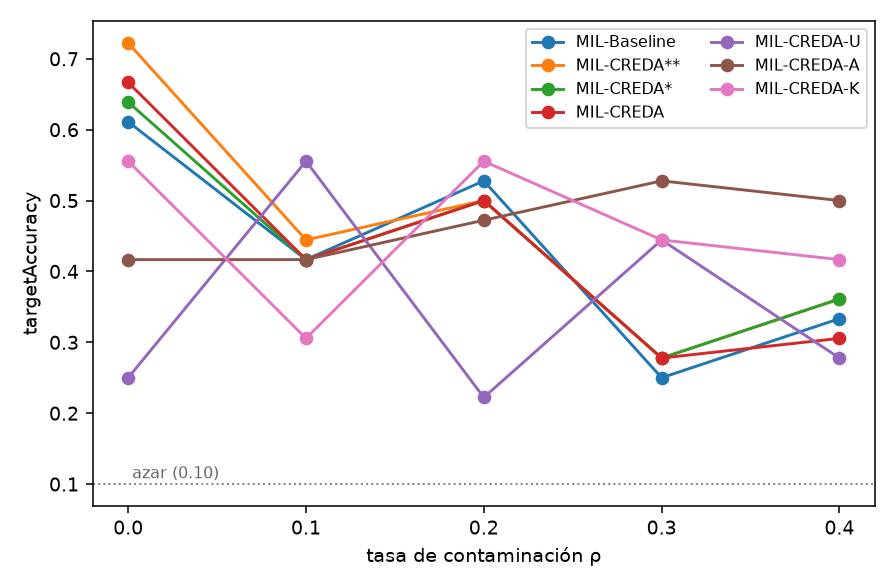

In [7]:
figura = figures.noise_curves("targetAccuracy",
                              config.noise_axis_for(ES_ENSAYO) / "degradation")
figures.inline(figura)

## 2 · Qué le pasa a la participación del término de adaptación

In [8]:
show(tables.objective("noise.share"))

> **Buscamos que la participación del término de adaptación suba con el ruido**, y que suba en los brazos que lo llevan y en ninguno más. Si no se mueve, el término está pesado para material limpio y la caída no dice si falló el término o si le faltó coeficiente.

In [9]:
show(tables.render_noise("adaptationShare", markdown=True))

| Método | ρ=0 | ρ=0.1 | ρ=0.2 | ρ=0.3 | ρ=0.4 |
|---|---|---|---|---|---|
| `MIL-Baseline` | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 |
| `MIL-CREDA**` | 0.08 | 0.03 | 0.03 | 0.02 | 0.02 |
| `MIL-CREDA*` | 0.07 | 0.02 | 0.03 | 0.01 | 0.02 |
| `MIL-CREDA` | 0.09 | 0.03 | 0.04 | 0.01 | 0.02 |
| `MIL-CREDA-U` | 0.07 | 0.05 | 0.03 | 0.02 | 0.02 |
| `MIL-CREDA-A` | 0.14 | 0.04 | 0.03 | 0.03 | 0.02 |
| `MIL-CREDA-K` | 0.06 | 0.03 | 0.02 | 0.02 | 0.01 |

In [10]:
show(tables.conclusion_noise("adaptationShare"))

Entre ρ=0 y ρ=0.4, `MIL-Baseline` es el que menos pierde (0.00) y `MIL-CREDA-A` el que más (0.12); el orden cambia: en limpio encabeza `MIL-CREDA-A` y contaminado encabeza `MIL-CREDA**`.

## 3 · El peldaño del peso por confianza

La mitad que las dos tablas de arriba no aíslan, y la que el destino contaminado
pone en juego. El destino entrena **sin etiquetas** — `pseudolabel` (Ec. 22) y
`confidences` (Ec. 24) —, así que contaminar sus bolsas no es ruido de etiqueta:
corrompe la condicional a la que el término de adaptación se alinea y envenena
los pseudo-rótulos de los que sale la confianza.

`D` contra `C`, y `F` y `G` contra `E`, difieren **exactamente** en ese peso. Con
material limpio ese peldaño casi no tiene nada que separarlo; es bajo ruido donde
el peso tiene algo que hacer, y por eso se lee acá y no en la campaña limpia.

In [11]:
show(tables.objective("noise.share"))

> **Buscamos que la participación del término de adaptación suba con el ruido**, y que suba en los brazos que lo llevan y en ninguno más. Si no se mueve, el término está pesado para material limpio y la caída no dice si falló el término o si le faltó coeficiente.

In [12]:
show(tables.conclusion_weighting_under_noise("targetAccuracy"))

El peldaño del peso por confianza, que es donde el destino contaminado tendría que notarse: `MIL-CREDA*` sobre `MIL-CREDA**` pasa de -8.3 en ρ=0 a +0.0 en ρ=0.4; `MIL-CREDA` sobre `MIL-CREDA**` pasa de -5.6 en ρ=0 a -5.6 en ρ=0.4.

## 4 · El registro

Lo que este cuaderno midió, escrito donde la declaración dice que vive. El
`records` del paquete nombra `Results/Noise/degradation.json` justamente para que
esto no aparezca después como un experimento que nadie contabilizó.

In [13]:
destino = config.noise_axis_for(ES_ENSAYO)
destino.mkdir(parents=True, exist_ok=True)
registro = {
    "transfer": TRANSFERENCIA,
    "levels": config.NOISE_LEVELS,
    "ran": corridos,
    "missing": faltan,
    "curves": {m: contamination.curve(m) for m in ("targetAccuracy", "adaptationShare")},
    "degradation": {m: contamination.degradation(m) for m in ("targetAccuracy", "adaptationShare")},
    "revision": config.REVISION,
}
(destino / "degradation.json").write_text(json.dumps(registro, indent=2), encoding="utf-8")
print(f"escrito: {destino / 'degradation.json'}")

escrito: /Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/MIL-CREDA/Results/Pilot/Noise/degradation.json


In [14]:
# El sello: contra qué código corrió este informe. Sin él, un informe viejo y uno
# recién generado se ven idénticos y el viejo se sigue creyendo.
from MIL_CREDA_Benchmark import report_digest

print(report_digest.stamp())

SOURCES-SHA256 a471d5af916db3d4f786ba3b229c65f7fbf217de3efa2f8b94367b01e4f68848
